# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 — Major Project**

This notebook analyzes agricultural performance across seasons (Kharif, Rabi, Zaid) using farm-level data on environmental conditions, resource usage, crop production, and economic outcomes.

**Goals:**
- Clean and prepare the dataset
- Compare seasonal performance across environmental, resource, and economic dimensions
- Identify patterns, relationships, and anomalies
- Derive evidence-based insights and recommendations


## 1. Setup & Data Loading

In [1]:
# Install/import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


In [4]:
# Load the dataset (update the filename/path if needed)
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (3).csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Initial Data Exploration
Understanding the structure, data types, and quality of the dataset before analysis.

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [7]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:\n", missing)

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check unique categorical values
for col in ['Season', 'State', 'Crop', 'Irrigation_Method']:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())


Columns with missing values:
 Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0

Season: 3 unique values
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

State: 8 unique values
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Crop: 8 unique values
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation_Method: 4 unique values
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


## 3. Data Cleaning & Preparation

- Missing `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha` values are imputed using the **median for their respective Season/Crop group** (more accurate than a single global median, since these metrics vary strongly by season).
- No duplicate rows were found.
- `Yield_Tonnes_Ha` has a handful of extreme outliers (likely data entry noise); we cap these at the 99th percentile for visualization purposes in a separate column, while keeping the original column intact for reference.


In [8]:
df_clean = df.copy()

# Impute missing values using season/crop-level medians
df_clean['Rainfall_mm'] = df_clean['Rainfall_mm'].fillna(
    df_clean.groupby('Season')['Rainfall_mm'].transform('median'))

df_clean['Soil_Moisture_pct'] = df_clean['Soil_Moisture_pct'].fillna(
    df_clean.groupby('Season')['Soil_Moisture_pct'].transform('median'))

df_clean['Yield_Tonnes_Ha'] = df_clean['Yield_Tonnes_Ha'].fillna(
    df_clean.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].transform('median'))

print("Remaining missing values:", df_clean.isnull().sum().sum())

# Cap extreme yield outliers (99th percentile) into a new column for cleaner plots
cap = df_clean['Yield_Tonnes_Ha'].quantile(0.99)
df_clean['Yield_Tonnes_Ha_capped'] = df_clean['Yield_Tonnes_Ha'].clip(upper=cap)

# Standardize season order for all plots
season_order = ['Kharif', 'Rabi', 'Zaid']
df_clean['Season'] = pd.Categorical(df_clean['Season'], categories=season_order, ordered=True)

df_clean.head()


Remaining missing values: 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Yield_Tonnes_Ha_capped
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,2.46
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,0.30
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,0.52
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,1.84
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,2.21


## 4. Seasonal Overview
Basic distribution of records and key averages across the three seasons.

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


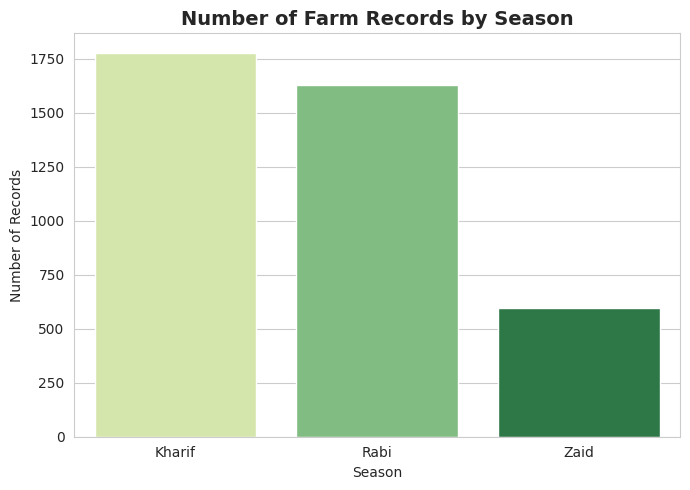

In [9]:
season_counts = df_clean['Season'].value_counts().reindex(season_order)
print(season_counts)

plt.figure(figsize=(7,5))
sns.barplot(x=season_counts.index, y=season_counts.values, hue=season_counts.index,
            palette='YlGn', legend=False)
plt.title('Number of Farm Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()


In [10]:
summary = df_clean.groupby('Season', observed=True)[
    ['Rainfall_mm','Avg_Temperature_C','Yield_Tonnes_Ha','Production_Tonnes',
     'Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
].mean().round(2)
summary


,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,852.11,28.45,5.63,46.31,178914.65,5.89,54.47
Rabi,435.94,23.49,5.09,41.49,87689.47,5.19,40.48
Zaid,299.12,31.04,4.64,38.89,-24804.82,4.41,38.22


## 5. Environmental Conditions Across Seasons
Comparing rainfall, temperature, humidity, and sunlight — the core drivers of seasonal variation.

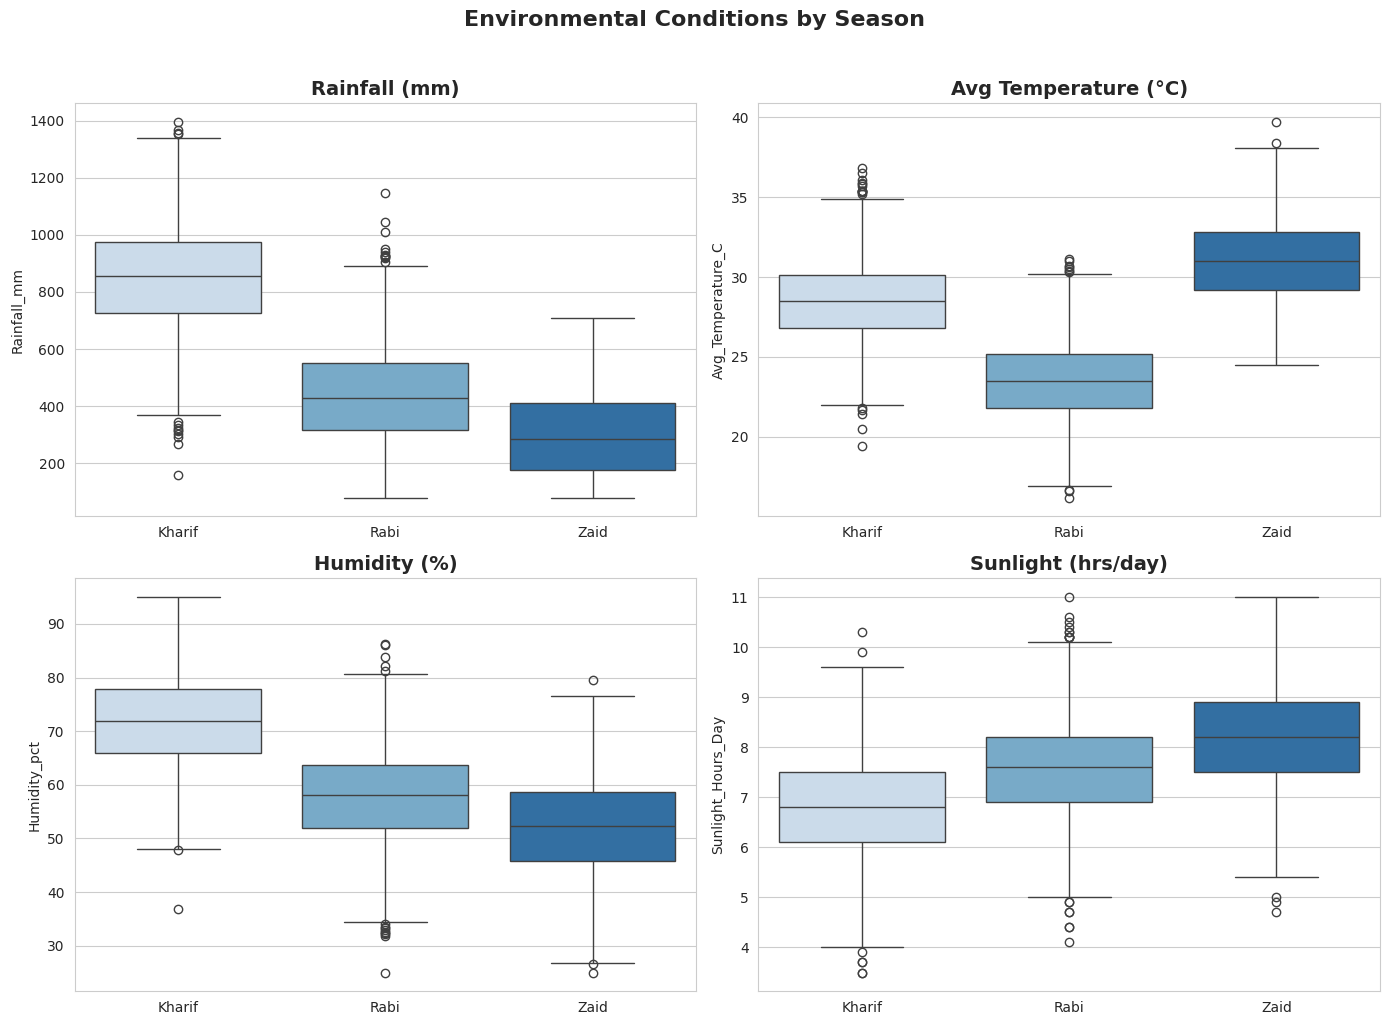

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

env_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']
titles = ['Rainfall (mm)', 'Avg Temperature (°C)', 'Humidity (%)', 'Sunlight (hrs/day)']

for ax, var, title in zip(axes.flat, env_vars, titles):
    sns.boxplot(data=df_clean, x='Season', y=var, hue='Season', order=season_order,
                palette='Blues', legend=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')

plt.suptitle('Environmental Conditions by Season', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Resource Usage Across Seasons
Fertilizer, pesticide, water usage, and irrigation method preferences by season.

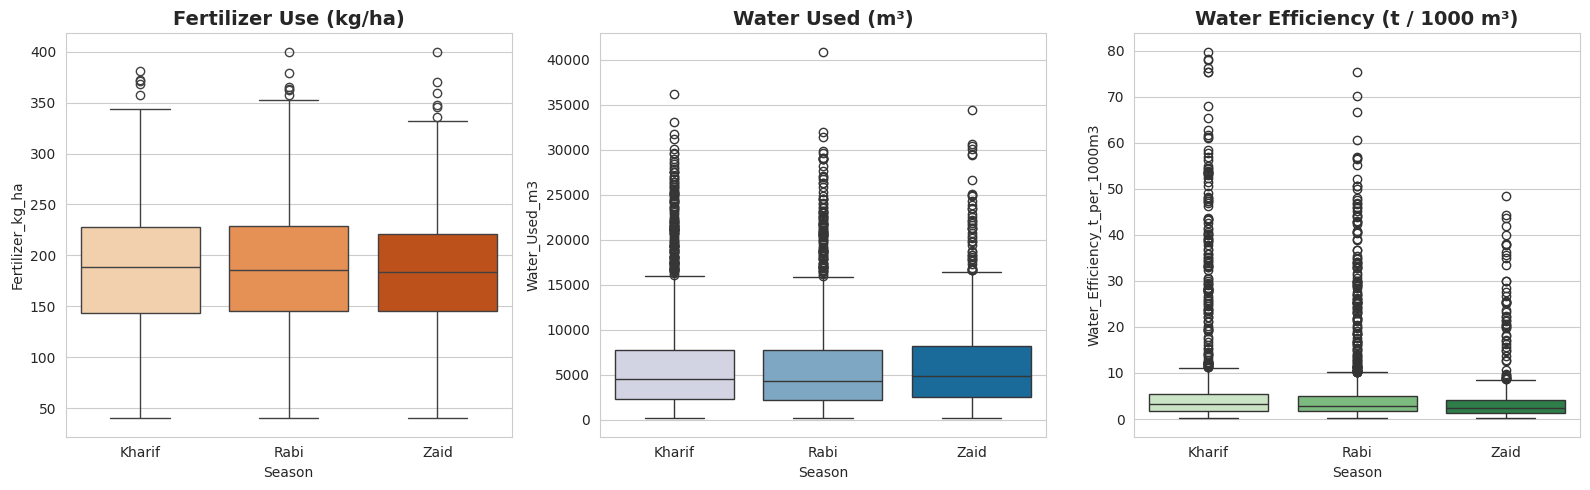

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_clean, x='Season', y='Fertilizer_kg_ha', hue='Season', order=season_order,
            palette='Oranges', legend=False, ax=axes[0])
axes[0].set_title('Fertilizer Use (kg/ha)')

sns.boxplot(data=df_clean, x='Season', y='Water_Used_m3', hue='Season', order=season_order,
            palette='PuBu', legend=False, ax=axes[1])
axes[1].set_title('Water Used (m³)')

sns.boxplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', hue='Season',
            order=season_order, palette='Greens', legend=False, ax=axes[2])
axes[2].set_title('Water Efficiency (t / 1000 m³)')

plt.tight_layout()
plt.show()


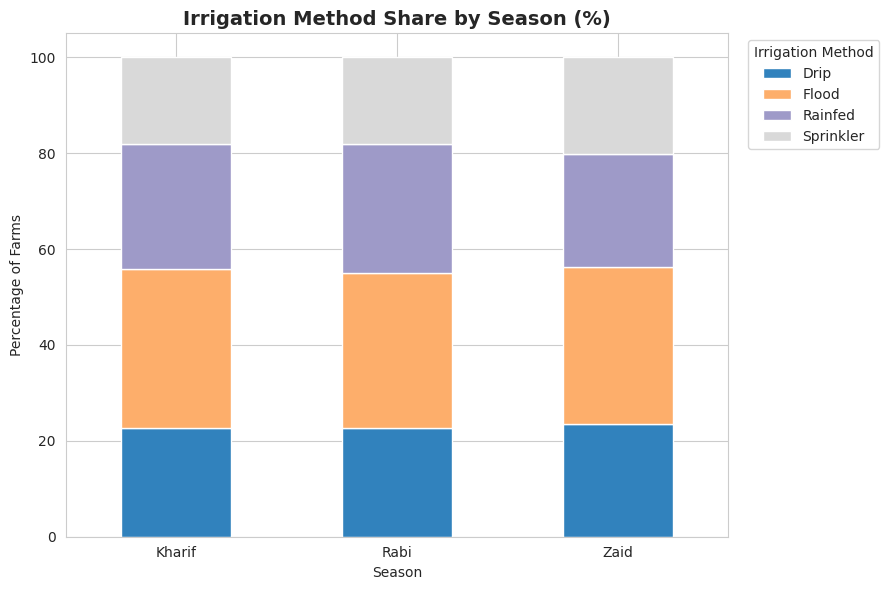

In [13]:
# Irrigation method preference by season
irrigation_ct = pd.crosstab(df_clean['Season'], df_clean['Irrigation_Method'], normalize='index') * 100

irrigation_ct.plot(kind='bar', stacked=True, figsize=(9,6), colormap='tab20c')
plt.title('Irrigation Method Share by Season (%)')
plt.ylabel('Percentage of Farms')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 7. Crop Production & Yield Across Seasons

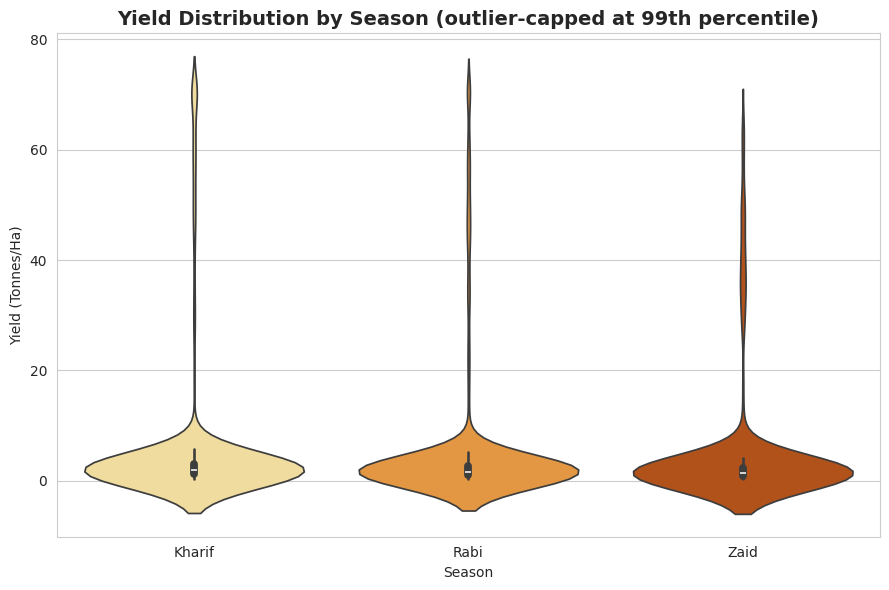

In [14]:
plt.figure(figsize=(9,6))
sns.violinplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha_capped', hue='Season',
               order=season_order, palette='YlOrBr', legend=False)
plt.title('Yield Distribution by Season (outlier-capped at 99th percentile)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


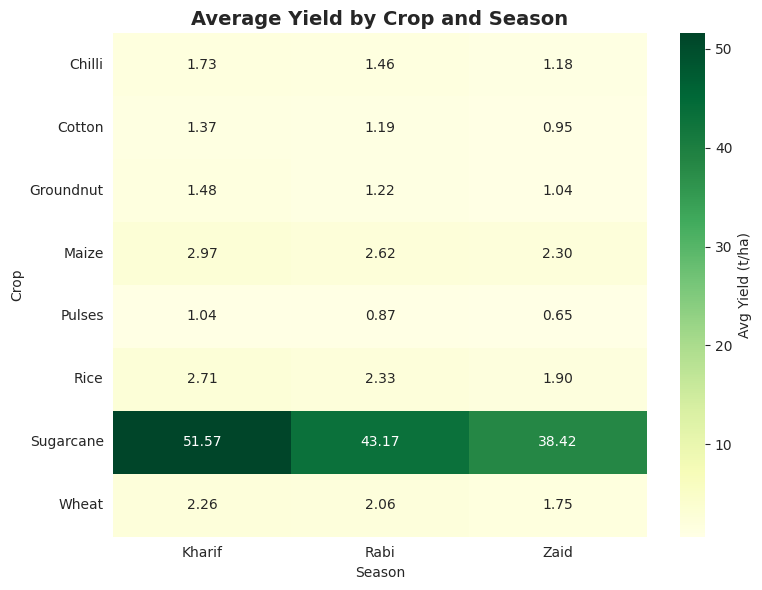

In [15]:
# Average yield by crop and season (heatmap)
pivot_yield = df_clean.pivot_table(values='Yield_Tonnes_Ha_capped', index='Crop',
                                    columns='Season', aggfunc='mean', observed=True)
pivot_yield = pivot_yield[season_order]

plt.figure(figsize=(8,6))
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGn', cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title('Average Yield by Crop and Season')
plt.tight_layout()
plt.show()


## 8. Economic Performance Across Seasons
Cost, revenue, and profit patterns by season.

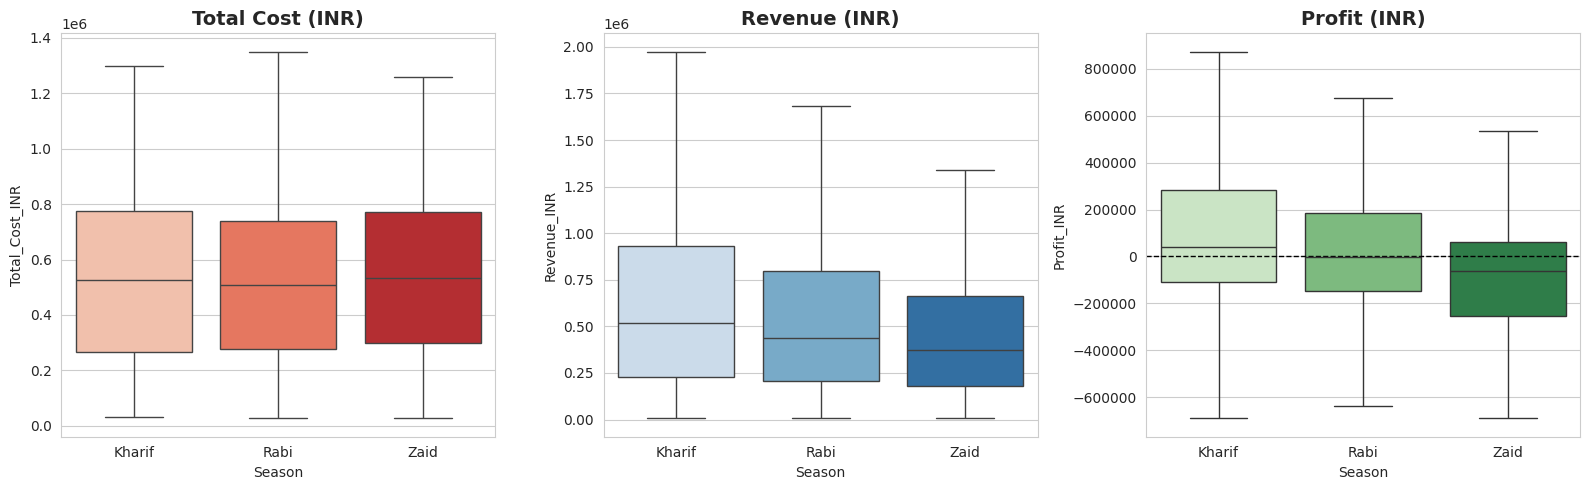

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_clean, x='Season', y='Total_Cost_INR', hue='Season', order=season_order,
            palette='Reds', legend=False, ax=axes[0], showfliers=False)
axes[0].set_title('Total Cost (INR)')

sns.boxplot(data=df_clean, x='Season', y='Revenue_INR', hue='Season', order=season_order,
            palette='Blues', legend=False, ax=axes[1], showfliers=False)
axes[1].set_title('Revenue (INR)')

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', hue='Season', order=season_order,
            palette='Greens', legend=False, ax=axes[2], showfliers=False)
axes[2].set_title('Profit (INR)')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


Percentage of loss-making farms by season:
 Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64


/tmp/ipykernel_4140/3979484829.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_share = df_clean.groupby('Season', observed=True).apply(


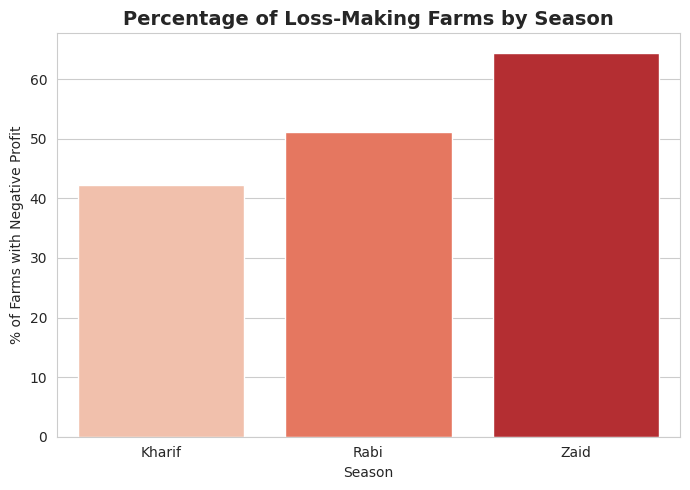

In [17]:
# Share of loss-making farms per season
loss_share = df_clean.groupby('Season', observed=True).apply(
    lambda x: (x['Profit_INR'] < 0).mean() * 100)
print("Percentage of loss-making farms by season:\n", loss_share.round(1))

plt.figure(figsize=(7,5))
sns.barplot(x=loss_share.index, y=loss_share.values, hue=loss_share.index,
            palette='Reds', legend=False)
plt.title('Percentage of Loss-Making Farms by Season')
plt.ylabel('% of Farms with Negative Profit')
plt.xlabel('Season')
plt.tight_layout()
plt.show()


## 9. Relationships Between Variables

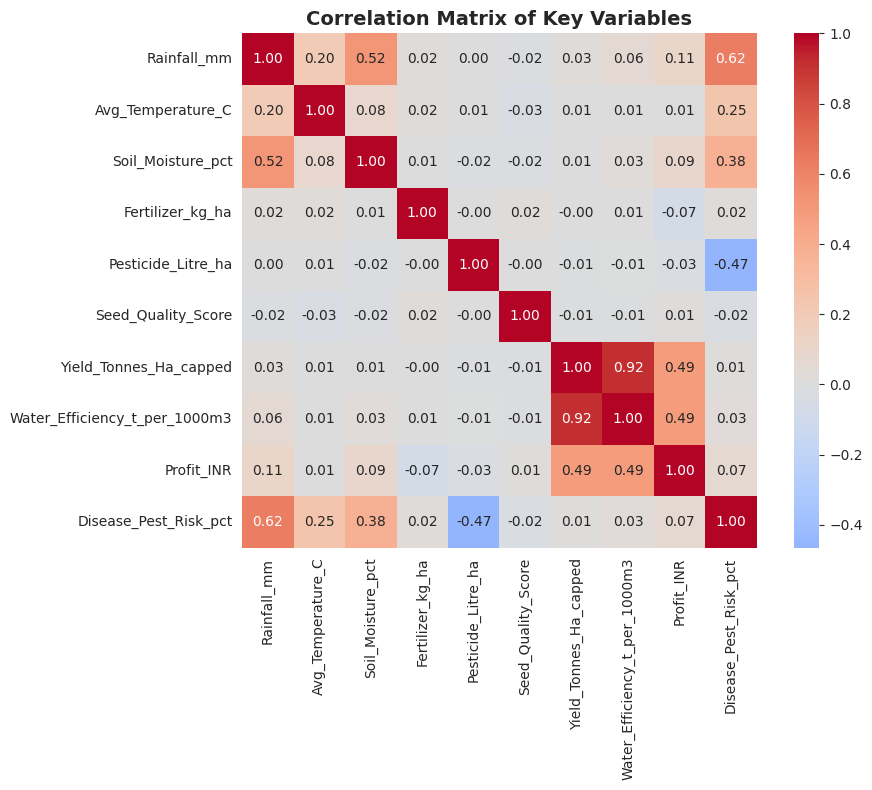

In [18]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Soil_Moisture_pct','Fertilizer_kg_ha',
            'Pesticide_Litre_ha','Seed_Quality_Score','Yield_Tonnes_Ha_capped',
            'Water_Efficiency_t_per_1000m3','Profit_INR','Disease_Pest_Risk_pct']

corr = df_clean[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()


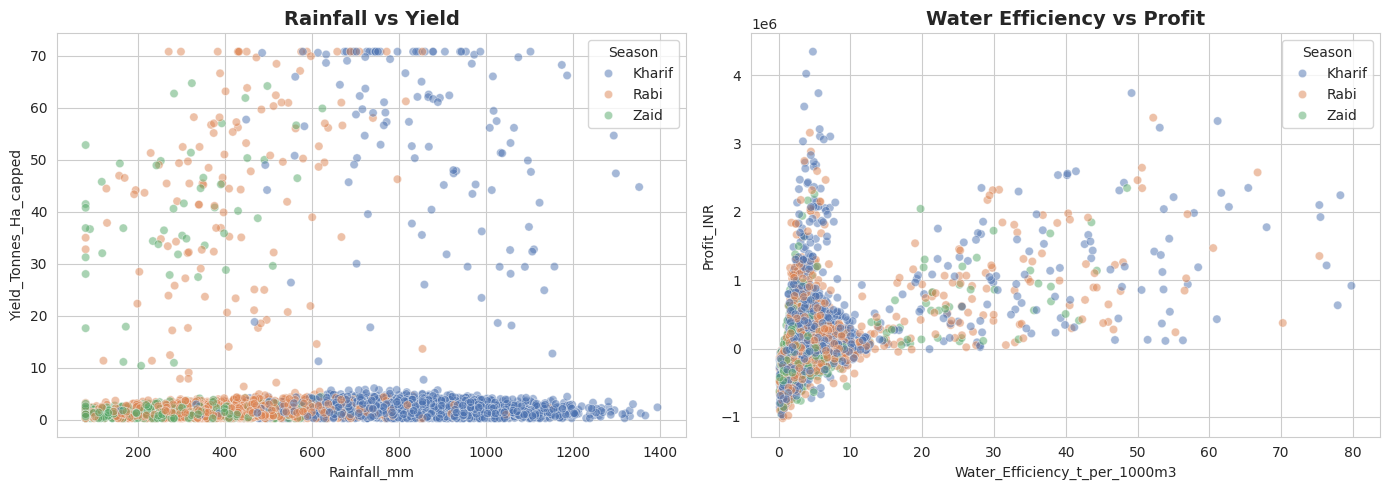

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=df_clean, x='Rainfall_mm', y='Yield_Tonnes_Ha_capped', hue='Season',
                 hue_order=season_order, palette='deep', alpha=0.5, ax=axes[0])
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df_clean, x='Water_Efficiency_t_per_1000m3', y='Profit_INR', hue='Season',
                 hue_order=season_order, palette='deep', alpha=0.5, ax=axes[1])
axes[1].set_title('Water Efficiency vs Profit')

plt.tight_layout()
plt.show()


## 10. Disease & Pest Risk Across Seasons

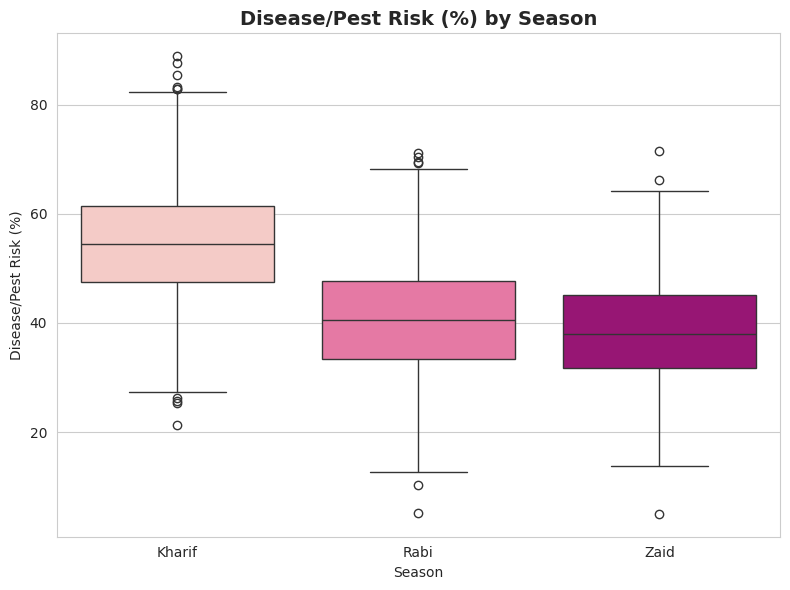

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', hue='Season',
            order=season_order, palette='RdPu', legend=False)
plt.title('Disease/Pest Risk (%) by Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.tight_layout()
plt.show()


## 11. Are Seasonal Patterns Consistent Across States?

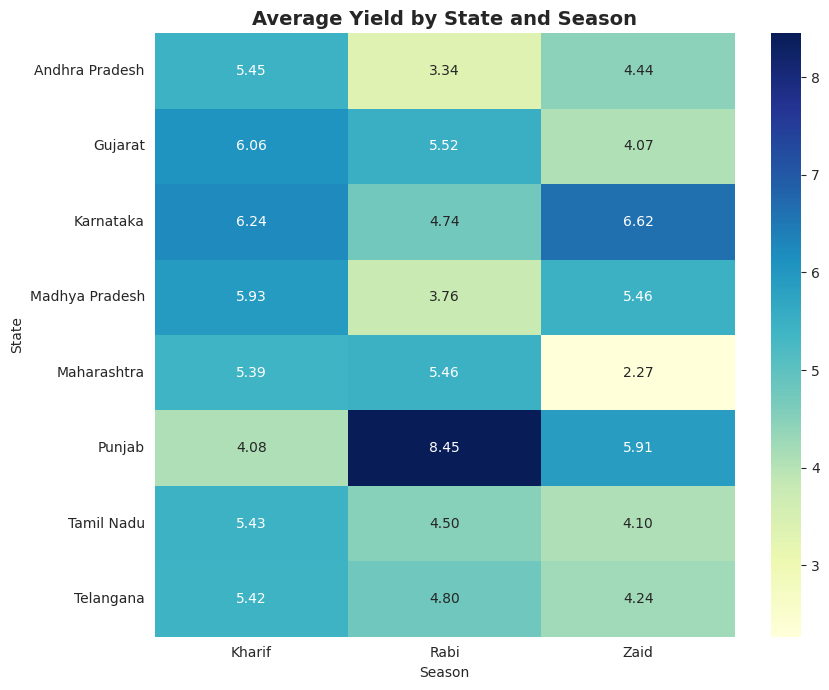

In [21]:
state_season_yield = df_clean.pivot_table(values='Yield_Tonnes_Ha_capped', index='State',
                                            columns='Season', aggfunc='mean', observed=True)
state_season_yield = state_season_yield[season_order]

plt.figure(figsize=(9,7))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yield by State and Season')
plt.tight_layout()
plt.show()


## 12. Key Findings

1. **Kharif** season shows the highest average rainfall and highest disease/pest risk, consistent with the monsoon-driven growing conditions.
2. **Rabi** and **Zaid** seasons show comparatively better water efficiency and lower pest risk, likely due to controlled irrigation and lower humidity.
3. Yield distributions vary meaningfully by crop **and** season — no single season is best for all crops, indicating the value of crop-specific seasonal planning.
4. A significant share of farms report **negative profit** in at least one season, suggesting cost pressures (fertilizer, pesticide, or water) outweigh revenue for many farms — this pattern should be investigated by crop and region.
5. Rainfall and yield show a **weak/moderate** relationship, implying yield is shaped by multiple interacting factors (soil quality, fertilizer, seed quality) rather than rainfall alone.
6. Seasonal yield patterns are **not fully consistent across states**, suggesting regional agro-climatic differences moderate the general seasonal trend.

## 13. Recommendations

- Prioritize water-efficient irrigation (drip/sprinkler) in Kharif season, where pest risk and water usage are both elevated.
- Target agricultural extension support toward crops/seasons showing high loss-making shares to improve cost efficiency.
- Encourage crop selection aligned with each state's strongest-performing season, based on the state-season yield heatmap.
- Further investigate outlier farms (very high yield or very high loss) as case studies for best/worst practice.
